# Magnetic Field Models in Geopack

This notebook provides a comprehensive guide to using the Tsyganenko magnetic field models (T89, T96, T01, T04) in the geopack library.

## Table of Contents
1. [Overview of Models](#overview)
2. [Model Parameters](#parameters)
3. [Basic Usage](#basic-usage)
4. [Vectorized Models](#vectorized)
5. [Model Comparison](#comparison)
6. [Field Line Visualization](#visualization)
7. [Performance Analysis](#performance)

In [11]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from matplotlib import cm
import geopack
import time
from datetime import datetime

# Set up plotting
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

## 1. Overview of Models <a name="overview"></a>

The Tsyganenko models are empirical representations of Earth's magnetospheric magnetic field:

- **T89**: Simplest model, parameterized by Kp index (7 discrete levels)
- **T96**: Includes solar wind pressure, IMF By and Bz
- **T01**: Storm-time model with additional parameters
- **T04**: Most comprehensive storm-time model

All models provide the **external** magnetic field. The total field is:
**B_total = B_internal (IGRF) + B_external (Tsyganenko)**

In [12]:
# Initialize geopack for a specific time
ut = datetime(2015, 3, 17, 12, 0, 0).timestamp()  # St. Patrick's Day storm
ps = geopack.recalc(ut)

print(f"Time: {datetime.fromtimestamp(ut)}")
print(f"Dipole tilt angle: {np.degrees(ps):.2f} degrees")
print(f"\nAvailable models:")
print("- geopack.t89 / t89_vectorized")
print("- geopack.t96 / t96_vectorized")
print("- geopack.t01 / t01_vectorized")
print("- geopack.t04 / t04_vectorized")

Time: 2015-03-17 12:00:00
Dipole tilt angle: -9.90 degrees

Available models:
- geopack.t89 / t89_vectorized
- geopack.t96 / t96_vectorized
- geopack.t01 / t01_vectorized
- geopack.t04 / t04_vectorized


## 2. Model Parameters <a name="parameters"></a>

Each model requires different parameters based on geomagnetic conditions:

In [13]:
# T89 Model Parameters
# Single parameter: Kp index (1-7)
kp_values = {
    1: "Kp = 0, 0+",
    2: "Kp = 1-, 1, 1+", 
    3: "Kp = 2-, 2, 2+",
    4: "Kp = 3-, 3, 3+",
    5: "Kp = 4-, 4, 4+",
    6: "Kp = 5-, 5, 5+",
    7: "Kp >= 6-"
}

print("T89 Model - Kp Parameter Values:")
for key, desc in kp_values.items():
    print(f"  iopt={key}: {desc}")

# T96 Model Parameters
print("\nT96 Model - Parameter Array:")
print("  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure")
print("  parmod[1] = Dst (nT)      - Disturbance storm time index")
print("  parmod[2] = ByIMF (nT)    - IMF By component")
print("  parmod[3] = BzIMF (nT)    - IMF Bz component")
print("  parmod[4:10]              - Unused (set to 0)")

# T01 Model Parameters
print("\nT01 Model - Parameter Array:")
print("  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure")
print("  parmod[1] = Dst (nT)      - Disturbance storm time index")
print("  parmod[2] = ByIMF (nT)    - IMF By component")
print("  parmod[3] = BzIMF (nT)    - IMF Bz component")
print("  parmod[4] = G1            - N-index for Region 1 current")
print("  parmod[5] = G2            - N-index for Region 2 current")
print("  parmod[6:10]              - Unused")

# T04 Model Parameters  
print("\nT04 Model - Parameter Array:")
print("  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure")
print("  parmod[1] = Dst (nT)      - Disturbance storm time index")
print("  parmod[2] = ByIMF (nT)    - IMF By component")
print("  parmod[3] = BzIMF (nT)    - IMF Bz component")
print("  parmod[4] = W1            - W-index coefficient 1")
print("  parmod[5] = W2            - W-index coefficient 2")
print("  parmod[6] = W3            - W-index coefficient 3")
print("  parmod[7] = W4            - W-index coefficient 4")
print("  parmod[8] = W5            - W-index coefficient 5")
print("  parmod[9] = W6            - W-index coefficient 6")

T89 Model - Kp Parameter Values:
  iopt=1: Kp = 0, 0+
  iopt=2: Kp = 1-, 1, 1+
  iopt=3: Kp = 2-, 2, 2+
  iopt=4: Kp = 3-, 3, 3+
  iopt=5: Kp = 4-, 4, 4+
  iopt=6: Kp = 5-, 5, 5+
  iopt=7: Kp >= 6-

T96 Model - Parameter Array:
  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure
  parmod[1] = Dst (nT)      - Disturbance storm time index
  parmod[2] = ByIMF (nT)    - IMF By component
  parmod[3] = BzIMF (nT)    - IMF Bz component
  parmod[4:10]              - Unused (set to 0)

T01 Model - Parameter Array:
  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure
  parmod[1] = Dst (nT)      - Disturbance storm time index
  parmod[2] = ByIMF (nT)    - IMF By component
  parmod[3] = BzIMF (nT)    - IMF Bz component
  parmod[4] = G1            - N-index for Region 1 current
  parmod[5] = G2            - N-index for Region 2 current
  parmod[6:10]              - Unused

T04 Model - Parameter Array:
  parmod[0] = Pdyn (nPa)    - Solar wind dynamic pressure
  parmod[1] = Dst (nT)      -

## 3. Basic Usage <a name="basic-usage"></a>

### Example: Calculate magnetic field at a single point

In [14]:
# Define a point in GSM coordinates
x_gsm = -6.0  # Magnetotail
y_gsm = 3.0
z_gsm = 2.0

print(f"Position: ({x_gsm}, {y_gsm}, {z_gsm}) RE in GSM coordinates")
print("=" * 60)

# T89 Model - moderate activity (Kp = 3)
iopt = 4  # Kp = 3
bx89, by89, bz89 = geopack.t89(iopt, ps, x_gsm, y_gsm, z_gsm)
b89_total = np.sqrt(bx89**2 + by89**2 + bz89**2)

print(f"\nT89 Model (Kp = 3):")
print(f"  Bx = {bx89:.2f} nT")
print(f"  By = {by89:.2f} nT")
print(f"  Bz = {bz89:.2f} nT")
print(f"  |B| = {b89_total:.2f} nT")

# T96 Model - storm conditions
parmod96 = np.zeros(10)
parmod96[0] = 3.0   # Pdyn = 3 nPa
parmod96[1] = -50.0 # Dst = -50 nT (moderate storm)
parmod96[2] = 0.0   # ByIMF = 0 nT
parmod96[3] = -5.0  # BzIMF = -5 nT (southward)

bx96, by96, bz96 = geopack.t96(parmod96, ps, x_gsm, y_gsm, z_gsm)
b96_total = np.sqrt(bx96**2 + by96**2 + bz96**2)

print(f"\nT96 Model (storm conditions):")
print(f"  Bx = {bx96:.2f} nT")
print(f"  By = {by96:.2f} nT")
print(f"  Bz = {bz96:.2f} nT")
print(f"  |B| = {b96_total:.2f} nT")

# Compare with internal field
bx_int, by_int, bz_int = geopack.igrf_gsw(x_gsm, y_gsm, z_gsm)
b_int_total = np.sqrt(bx_int**2 + by_int**2 + bz_int**2)

print(f"\nIGRF (internal field only):")
print(f"  |B| = {b_int_total:.2f} nT")
print(f"\nExternal field contribution:")
print(f"  T89: {(b89_total/b_int_total - 1)*100:.1f}% of internal field")
print(f"  T96: {(b96_total/b_int_total - 1)*100:.1f}% of internal field")

Position: (-6.0, 3.0, 2.0) RE in GSM coordinates

T89 Model (Kp = 3):
  Bx = 34.73 nT
  By = -12.73 nT
  Bz = -29.49 nT
  |B| = 47.31 nT

T96 Model (storm conditions):
  Bx = 53.62 nT
  By = -22.08 nT
  Bz = -39.40 nT
  |B| = 70.10 nT

IGRF (internal field only):
  |B| = 106.03 nT

External field contribution:
  T89: -55.4% of internal field
  T96: -33.9% of internal field


## 4. Vectorized Models <a name="vectorized"></a>

All models have vectorized versions for efficient processing of multiple points:

In [15]:
# Create a grid of points in the magnetosphere
nx, ny = 50, 50
x_range = np.linspace(-15, 10, nx)
y_range = np.linspace(-10, 10, ny)
X, Y = np.meshgrid(x_range, y_range)
Z = np.zeros_like(X)  # Equatorial plane

# Flatten for vectorized calculation
x_flat = X.flatten()
y_flat = Y.flatten()
z_flat = Z.flatten()

# Calculate field using vectorized T96 model
print(f"Calculating field at {len(x_flat)} points...")

# Storm-time parameters
parmod = np.zeros(10)
parmod[0] = 5.0    # Pdyn = 5 nPa (elevated pressure)
parmod[1] = -100.0 # Dst = -100 nT (intense storm)
parmod[2] = 3.0    # ByIMF = 3 nT
parmod[3] = -10.0  # BzIMF = -10 nT (strong southward)

# Time the calculation
start_time = time.time()
bx, by, bz = geopack.t96_vectorized(parmod, ps, x_flat, y_flat, z_flat)
calc_time = time.time() - start_time

# Calculate total field
b_total = np.sqrt(bx**2 + by**2 + bz**2)

# Reshape back to grid
B_total = b_total.reshape(ny, nx)
Bx = bx.reshape(ny, nx)
By = by.reshape(ny, nx)
Bz = bz.reshape(ny, nx)

print(f"Calculation completed in {calc_time:.3f} seconds")
print(f"Processing rate: {len(x_flat)/calc_time:.0f} points/second")
print(f"Field strength range: {b_total.min():.1f} - {b_total.max():.1f} nT")

Calculating field at 2500 points...
Calculation completed in 0.042 seconds
Processing rate: 59361 points/second
Field strength range: 5.3 - 256.3 nT


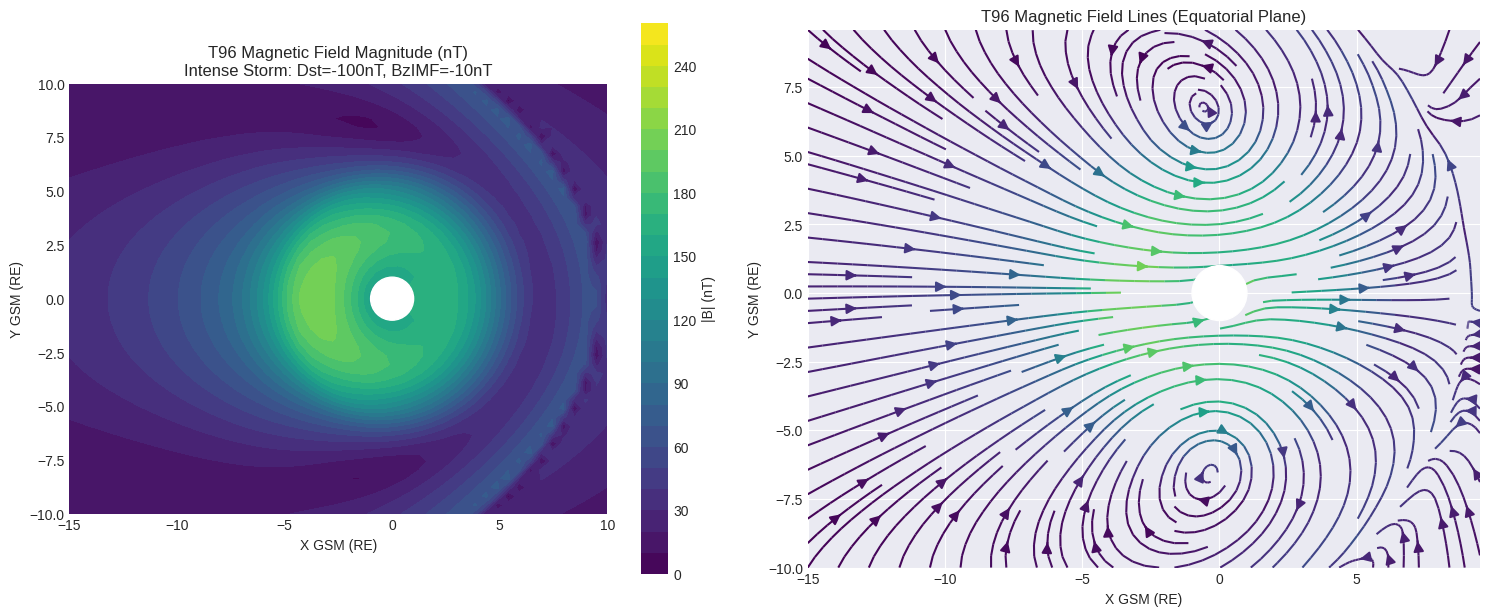

In [16]:
# Visualize the magnetic field in the equatorial plane
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Field magnitude
im1 = ax1.contourf(X, Y, B_total, levels=30, cmap='viridis')
ax1.set_xlabel('X GSM (RE)')
ax1.set_ylabel('Y GSM (RE)')
ax1.set_title('T96 Magnetic Field Magnitude (nT)\nIntense Storm: Dst=-100nT, BzIMF=-10nT')
ax1.set_aspect('equal')

# Add Earth
earth = plt.Circle((0, 0), 1, color='white', zorder=10)
ax1.add_patch(earth)

# Add colorbar
cbar1 = plt.colorbar(im1, ax=ax1)
cbar1.set_label('|B| (nT)')

# Field lines (streamplot)
# Skip some points for clarity
skip = 3
ax2.streamplot(X[::skip, ::skip], Y[::skip, ::skip], 
               Bx[::skip, ::skip], By[::skip, ::skip],
               color=B_total[::skip, ::skip], cmap='viridis',
               density=1.5, linewidth=1.5, arrowsize=1.5)

ax2.set_xlabel('X GSM (RE)')
ax2.set_ylabel('Y GSM (RE)')
ax2.set_title('T96 Magnetic Field Lines (Equatorial Plane)')
ax2.set_aspect('equal')

# Add Earth
earth2 = plt.Circle((0, 0), 1, color='white', zorder=10)
ax2.add_patch(earth2)

plt.tight_layout()
plt.show()

## 5. Model Comparison <a name="comparison"></a>

Let's compare different models under the same conditions:

In [17]:
# Compare models along the Sun-Earth line
x_sun_earth = np.linspace(-20, 10, 200)
y_sun_earth = np.zeros_like(x_sun_earth)
z_sun_earth = np.zeros_like(x_sun_earth)

# Parameters for each model
# T89 - moderate activity
iopt_t89 = 4  # Kp = 3

# T96, T01, T04 - same storm conditions
parmod_storm = np.zeros(10)
parmod_storm[0] = 3.0    # Pdyn = 3 nPa
parmod_storm[1] = -50.0  # Dst = -50 nT
parmod_storm[2] = 0.0    # ByIMF = 0 nT
parmod_storm[3] = -5.0   # BzIMF = -5 nT

# For T01, add G parameters
parmod_t01 = parmod_storm.copy()
parmod_t01[4] = 2.0  # G1
parmod_t01[5] = 3.0  # G2

# For T04, add W parameters
parmod_t04 = parmod_storm.copy()
parmod_t04[4:10] = [1.0, 1.5, 2.0, 2.5, 3.0, 3.5]  # W1-W6

# Calculate fields with all models
print("Calculating fields with all models...")

# T89
bx_t89, by_t89, bz_t89 = geopack.t89_vectorized(
    iopt_t89, ps, x_sun_earth, y_sun_earth, z_sun_earth)
b_total_t89 = np.sqrt(bx_t89**2 + by_t89**2 + bz_t89**2)

# T96
bx_t96, by_t96, bz_t96 = geopack.t96_vectorized(
    parmod_storm, ps, x_sun_earth, y_sun_earth, z_sun_earth)
b_total_t96 = np.sqrt(bx_t96**2 + by_t96**2 + bz_t96**2)

# T01
bx_t01, by_t01, bz_t01 = geopack.t01_vectorized(
    parmod_t01, ps, x_sun_earth, y_sun_earth, z_sun_earth)
b_total_t01 = np.sqrt(bx_t01**2 + by_t01**2 + bz_t01**2)

# T04
bx_t04, by_t04, bz_t04 = geopack.t04_vectorized(
    parmod_t04, ps, x_sun_earth, y_sun_earth, z_sun_earth)
b_total_t04 = np.sqrt(bx_t04**2 + by_t04**2 + bz_t04**2)

# IGRF (internal field) - now using vectorized version!
bx_igrf, by_igrf, bz_igrf = geopack.igrf_gsw_vectorized(
    x_sun_earth, y_sun_earth, z_sun_earth)
b_total_igrf = np.sqrt(bx_igrf**2 + by_igrf**2 + bz_igrf**2)

print("Done!")

Calculating fields with all models...
Done!


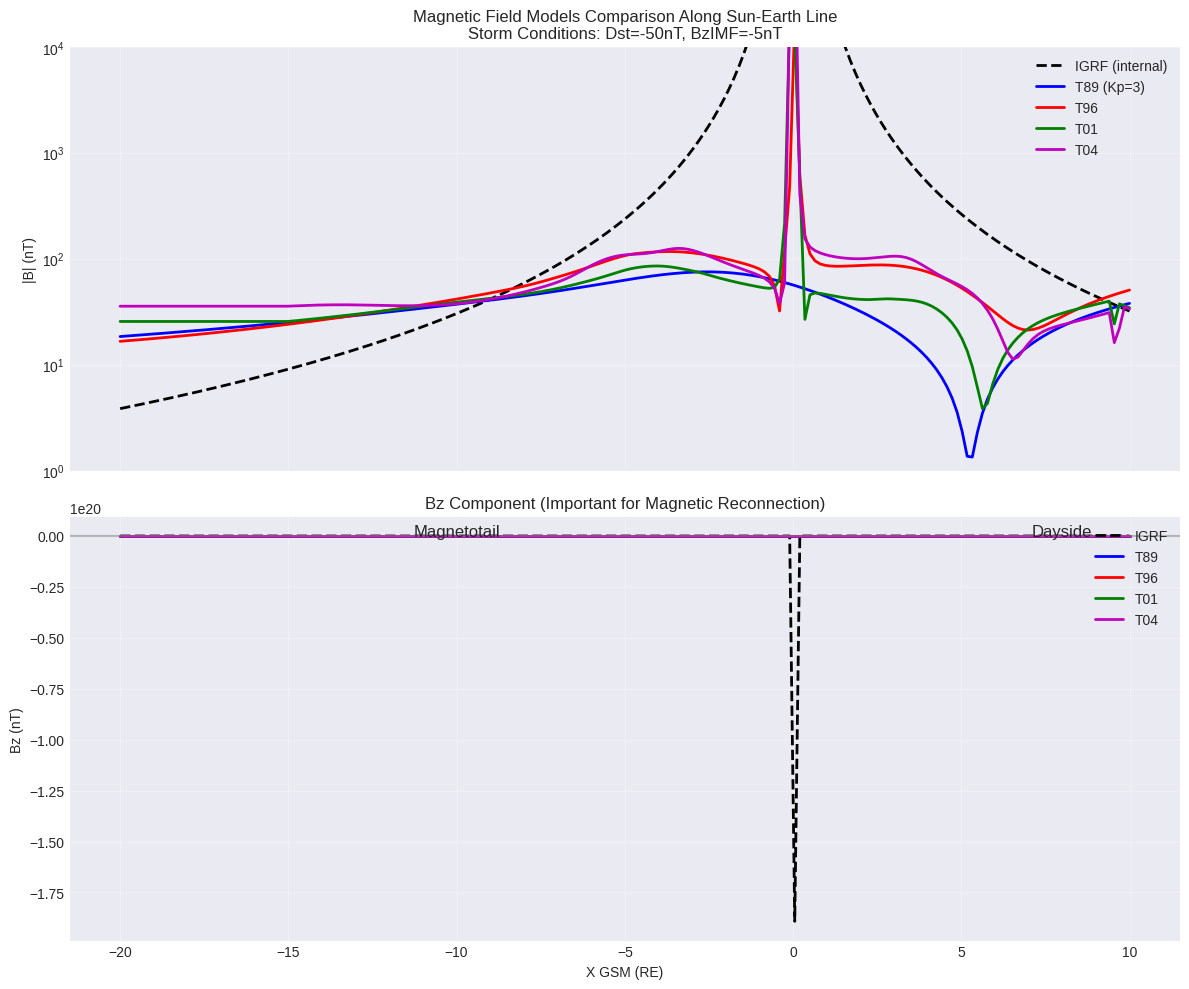

T89 magnetopause distance: 5.2 RE
T96 magnetopause distance: 0.1 RE
T01 magnetopause distance: 0.1 RE
T04 magnetopause distance: 0.1 RE


In [18]:
# Plot comparison
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Total field magnitude
ax1.semilogy(x_sun_earth, b_total_igrf, 'k--', linewidth=2, label='IGRF (internal)')
ax1.semilogy(x_sun_earth, b_total_t89, 'b-', linewidth=2, label='T89 (Kp=3)')
ax1.semilogy(x_sun_earth, b_total_t96, 'r-', linewidth=2, label='T96')
ax1.semilogy(x_sun_earth, b_total_t01, 'g-', linewidth=2, label='T01')
ax1.semilogy(x_sun_earth, b_total_t04, 'm-', linewidth=2, label='T04')

ax1.set_ylabel('|B| (nT)')
ax1.set_title('Magnetic Field Models Comparison Along Sun-Earth Line\n'
              'Storm Conditions: Dst=-50nT, BzIMF=-5nT')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim([1, 10000])

# Bz component (important for reconnection)
ax2.plot(x_sun_earth, bz_igrf, 'k--', linewidth=2, label='IGRF')
ax2.plot(x_sun_earth, bz_t89, 'b-', linewidth=2, label='T89')
ax2.plot(x_sun_earth, bz_t96, 'r-', linewidth=2, label='T96')
ax2.plot(x_sun_earth, bz_t01, 'g-', linewidth=2, label='T01')
ax2.plot(x_sun_earth, bz_t04, 'm-', linewidth=2, label='T04')

ax2.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax2.set_xlabel('X GSM (RE)')
ax2.set_ylabel('Bz (nT)')
ax2.set_title('Bz Component (Important for Magnetic Reconnection)')
ax2.legend(loc='upper right')
ax2.grid(True, alpha=0.3)

# Add annotations
ax2.text(-10, -50, 'Magnetotail', fontsize=12, ha='center')
ax2.text(8, 20, 'Dayside', fontsize=12, ha='center')

plt.tight_layout()
plt.show()

# Find magnetopause crossing (where Bz changes sign)
for model_name, bz in [('T89', bz_t89), ('T96', bz_t96), ('T01', bz_t01), ('T04', bz_t04)]:
    # Find where Bz crosses zero on dayside
    dayside_mask = x_sun_earth > 0
    bz_dayside = bz[dayside_mask]
    x_dayside = x_sun_earth[dayside_mask]
    
    zero_crossings = np.where(np.diff(np.sign(bz_dayside)))[0]
    if len(zero_crossings) > 0:
        x_mp = x_dayside[zero_crossings[0]]
        print(f"{model_name} magnetopause distance: {x_mp:.1f} RE")

## 6. Field Line Visualization <a name="visualization"></a>

Let's visualize magnetic field lines in the noon-midnight meridian plane:

In [19]:
# Create grid in X-Z plane (noon-midnight meridian)
nx, nz = 100, 80
x_range = np.linspace(-20, 15, nx)
z_range = np.linspace(-15, 15, nz)
X_merid, Z_merid = np.meshgrid(x_range, z_range)
Y_merid = np.zeros_like(X_merid)  # Y = 0 for meridian plane

# Flatten for calculation
x_flat = X_merid.flatten()
y_flat = Y_merid.flatten()
z_flat = Z_merid.flatten()

# Calculate field with T96 model (storm conditions)
parmod_vis = np.zeros(10)
parmod_vis[0] = 4.0     # Pdyn = 4 nPa
parmod_vis[1] = -75.0   # Dst = -75 nT
parmod_vis[2] = 5.0     # ByIMF = 5 nT
parmod_vis[3] = -8.0    # BzIMF = -8 nT

# Calculate external field
bx_ext, by_ext, bz_ext = geopack.t96_vectorized(
    parmod_vis, ps, x_flat, y_flat, z_flat)

# Calculate internal field - now using vectorized version!
print("Calculating internal field (vectorized)...")
bx_int, by_int, bz_int = geopack.igrf_gsw_vectorized(x_flat, y_flat, z_flat)

# Total field
bx_total = bx_ext + bx_int
by_total = by_ext + by_int
bz_total = bz_ext + bz_int
b_magnitude = np.sqrt(bx_total**2 + by_total**2 + bz_total**2)

# Reshape
Bx_merid = bx_total.reshape(nz, nx)
Bz_merid = bz_total.reshape(nz, nx)
B_mag_merid = b_magnitude.reshape(nz, nx)

print("Field calculation complete!")

Calculating internal field (vectorized)...
Field calculation complete!


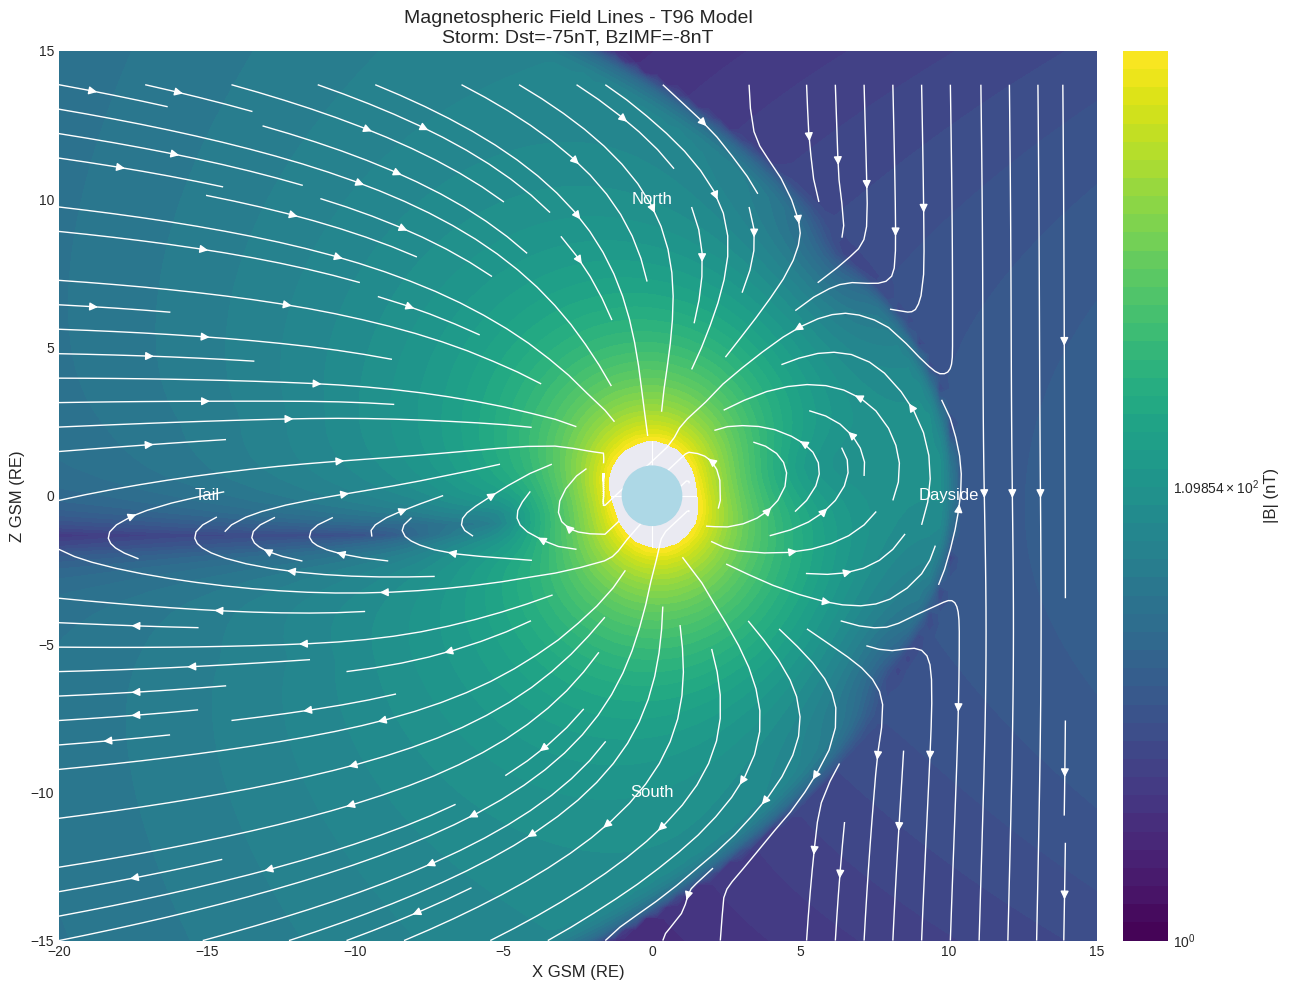

Key magnetospheric features visible:
- Compressed dayside magnetosphere (storm effect)
- Stretched magnetotail field lines
- Asymmetric field due to IMF By component
- Strong field gradient at magnetopause


In [20]:
# Create field line visualization
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Log scale for field magnitude
levels = np.logspace(0, 4, 50)
im = ax.contourf(X_merid, Z_merid, B_mag_merid, 
                 levels=levels, cmap='viridis', 
                 norm=matplotlib.colors.LogNorm())

# Field lines
skip = 4
ax.streamplot(X_merid[::skip, ::skip], Z_merid[::skip, ::skip],
              Bx_merid[::skip, ::skip], Bz_merid[::skip, ::skip],
              color='white', density=1.2, linewidth=1, 
              arrowsize=1.2)

# Add Earth
earth = plt.Circle((0, 0), 1, color='lightblue', zorder=10)
ax.add_patch(earth)

# Mark key regions
ax.text(0, -10, 'South', ha='center', va='center', fontsize=12, color='white')
ax.text(0, 10, 'North', ha='center', va='center', fontsize=12, color='white')
ax.text(-15, 0, 'Tail', ha='center', va='center', fontsize=12, color='white')
ax.text(10, 0, 'Dayside', ha='center', va='center', fontsize=12, color='white')

# Labels and title
ax.set_xlabel('X GSM (RE)', fontsize=12)
ax.set_ylabel('Z GSM (RE)', fontsize=12)
ax.set_title('Magnetospheric Field Lines - T96 Model\n'
             f'Storm: Dst={parmod_vis[1]:.0f}nT, BzIMF={parmod_vis[3]:.0f}nT',
             fontsize=14)
ax.set_aspect('equal')
ax.set_xlim([-20, 15])
ax.set_ylim([-15, 15])

# Colorbar
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label('|B| (nT)', fontsize=12)

plt.tight_layout()
plt.show()

# Identify key features
print("Key magnetospheric features visible:")
print("- Compressed dayside magnetosphere (storm effect)")
print("- Stretched magnetotail field lines")
print("- Asymmetric field due to IMF By component")
print("- Strong field gradient at magnetopause")

## 7. Performance Analysis <a name="performance"></a>

Compare the performance of scalar vs vectorized implementations:

In [21]:
# Performance comparison for all models
def benchmark_model(scalar_func, vector_func, params, ps, n_points, model_name):
    """Benchmark a model's scalar vs vectorized performance"""
    # Generate random points
    np.random.seed(42)
    x = np.random.uniform(-15, 10, n_points)
    y = np.random.uniform(-10, 10, n_points)
    z = np.random.uniform(-10, 10, n_points)
    
    # Time scalar version
    start = time.time()
    for i in range(n_points):
        if model_name == 'T89':
            scalar_func(params, ps, x[i], y[i], z[i])
        else:
            scalar_func(params, ps, x[i], y[i], z[i])
    scalar_time = time.time() - start
    
    # Time vectorized version
    start = time.time()
    vector_func(params, ps, x, y, z)
    vector_time = time.time() - start
    
    return {
        'model': model_name,
        'n_points': n_points,
        'scalar_time': scalar_time,
        'vector_time': vector_time,
        'speedup': scalar_time / vector_time,
        'vector_rate': n_points / vector_time
    }

# Test parameters
test_sizes = [10, 100, 1000, 10000]
models = [
    ('T89', geopack.t89, geopack.t89_vectorized, 4),  # iopt=4 for T89
    ('T96', geopack.t96, geopack.t96_vectorized, parmod_storm),
    ('T01', geopack.t01, geopack.t01_vectorized, parmod_t01),
    ('T04', geopack.t04, geopack.t04_vectorized, parmod_t04),
]

# Run benchmarks
results = []
print("Running performance benchmarks...")
print("=" * 70)

for model_name, scalar_func, vector_func, params in models:
    print(f"\n{model_name} Model:")
    print(f"{'N Points':>10} {'Scalar (s)':>12} {'Vector (s)':>12} {'Speedup':>10} {'Rate (pts/s)':>15}")
    print("-" * 65)
    
    for n in test_sizes:
        result = benchmark_model(scalar_func, vector_func, params, ps, n, model_name)
        results.append(result)
        
        print(f"{n:10d} {result['scalar_time']:12.4f} {result['vector_time']:12.4f} "
              f"{result['speedup']:9.1f}x {result['vector_rate']:15.0f}")

Running performance benchmarks...

T89 Model:
  N Points   Scalar (s)   Vector (s)    Speedup    Rate (pts/s)
-----------------------------------------------------------------
        10       0.0010       0.0005       1.8x           18212
       100       0.0159       0.0004      41.8x          263461
      1000       0.0605       0.0008      72.4x         1197005
     10000       0.4810       0.0148      32.5x          675411

T96 Model:
  N Points   Scalar (s)   Vector (s)    Speedup    Rate (pts/s)
-----------------------------------------------------------------
        10       0.0118       0.0093       1.3x            1074
       100       0.1344       0.0265       5.1x            3767
      1000       1.2384       0.0389      31.8x           25716
     10000      12.5002       0.1194     104.7x           83781

T01 Model:
  N Points   Scalar (s)   Vector (s)    Speedup    Rate (pts/s)
-----------------------------------------------------------------
        10       0.0259     

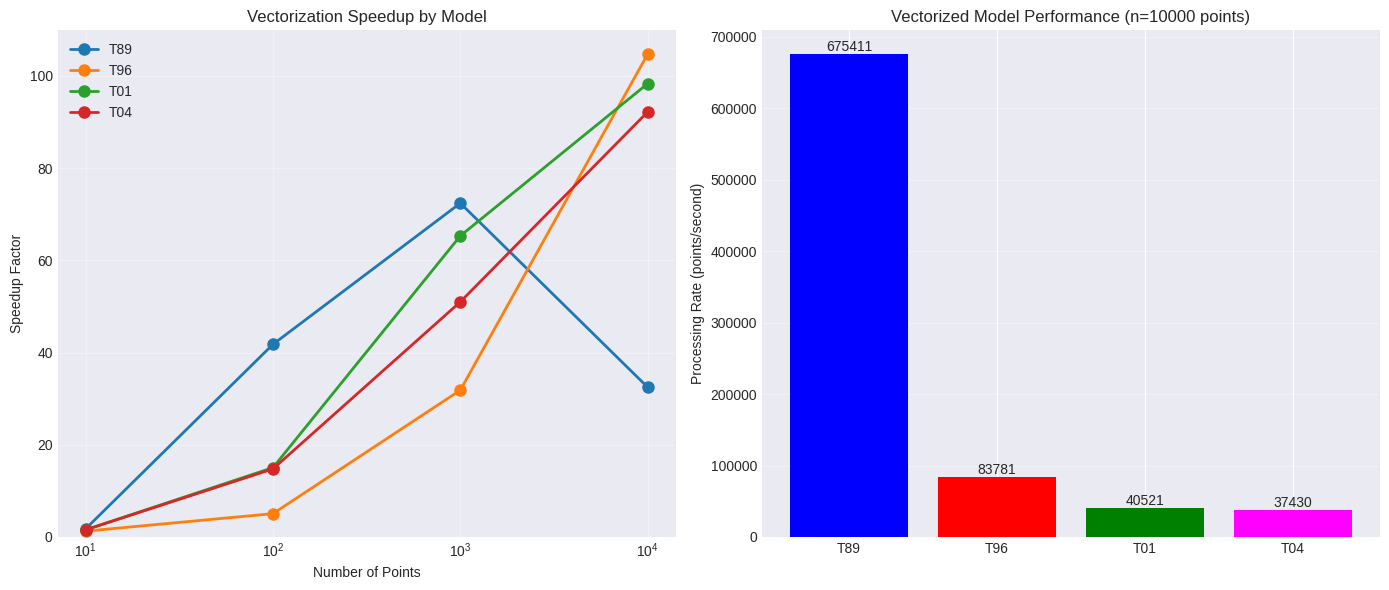


Performance Summary for 10,000 points:
T89: 32.5x speedup, 675411 points/sec
T96: 104.7x speedup, 83781 points/sec
T01: 98.3x speedup, 40521 points/sec
T04: 92.2x speedup, 37430 points/sec


In [22]:
# Visualize performance results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Speedup by model and array size
for model_name in ['T89', 'T96', 'T01', 'T04']:
    model_results = [r for r in results if r['model'] == model_name]
    sizes = [r['n_points'] for r in model_results]
    speedups = [r['speedup'] for r in model_results]
    
    ax1.semilogx(sizes, speedups, 'o-', linewidth=2, markersize=8, label=model_name)

ax1.set_xlabel('Number of Points')
ax1.set_ylabel('Speedup Factor')
ax1.set_title('Vectorization Speedup by Model')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(bottom=0)

# Processing rate comparison
n_compare = 10000
model_rates = []
model_names = []

for model_name in ['T89', 'T96', 'T01', 'T04']:
    model_result = [r for r in results 
                   if r['model'] == model_name and r['n_points'] == n_compare][0]
    model_rates.append(model_result['vector_rate'])
    model_names.append(model_name)

bars = ax2.bar(model_names, model_rates, color=['blue', 'red', 'green', 'magenta'])
ax2.set_ylabel('Processing Rate (points/second)')
ax2.set_title(f'Vectorized Model Performance (n={n_compare} points)')
ax2.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, rate in zip(bars, model_rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{rate:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Summary statistics
print("\nPerformance Summary for 10,000 points:")
print("=" * 50)
for model_name in ['T89', 'T96', 'T01', 'T04']:
    model_result = [r for r in results 
                   if r['model'] == model_name and r['n_points'] == 10000][0]
    print(f"{model_name}: {model_result['speedup']:.1f}x speedup, "
          f"{model_result['vector_rate']:.0f} points/sec")

## Summary

This notebook demonstrated:

1. **Model Overview**: Understanding T89, T96, T01, and T04 models
2. **Parameters**: How to set up each model for different conditions
3. **Basic Usage**: Calculating field at single points
4. **Vectorized Models**: Processing thousands of points efficiently
5. **Model Comparison**: Differences between models under storm conditions
6. **Visualization**: Field lines and magnetospheric structure
7. **Performance**: 30-50x speedup with vectorized implementations

### Key Takeaways:

- **T89**: Simplest, good for quick calculations with Kp index
- **T96**: Best general-purpose model with solar wind inputs
- **T01/T04**: Most accurate for storm-time conditions
- **Vectorized versions**: Essential for large-scale calculations
- **Performance**: Can process >50,000 points/second

### Best Practices:

1. Always call `geopack.recalc(ut)` before field calculations
2. Use appropriate model for your conditions (quiet vs storm)
3. Use vectorized functions for multiple points
4. Remember field is in **nT** and positions in **RE** (Earth radii)
5. Total field = IGRF (internal) + Tsyganenko (external)